In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)

C:\Users\Alina\AppData\Local\Temp\ipykernel_10472\3062298247.py:1: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)


In [3]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#je génère 2 nouveaux dataframes, un avec les aliments qui ont un nutriscore connu et un autre avec ceux qui n'ont pas de nutriscore connu.

# DataFrame avec les nutriscores connus (a, b, c, d, e)
scores_connus = ['a', 'b', 'c', 'd', 'e']
df_connu = df[df['nutriscore_grade'].isin(scores_connus)].copy()

# DataFrame avec le reste (unknown, not-applicable, ou NaN éventuels)
df_inconnu = df[~df['nutriscore_grade'].isin(scores_connus)].copy()

# Vérification rapide
print("Connu :", df_connu.shape)
print("Inconnu :", df_inconnu.shape)
print(df_connu['nutriscore_grade'].value_counts())
print(df_inconnu['nutriscore_grade'].value_counts(dropna=False))

Connu : (965, 211)
Inconnu : (9035, 211)
nutriscore_grade
e    306
d    209
c    190
a    171
b     89
Name: count, dtype: int64
nutriscore_grade
unknown           8455
NaN                313
not-applicable     267
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

X = df_connu[features]  # Seules CES colonnes sont sélectionnées, tout le reste est ignoré
y = df_connu['nutriscore_grade']    

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split.

In [6]:
#Nettoyage minimal des données
percent_missing = df_connu[features].isnull().sum() * 100 / len(df_connu)
percent_missing.sort_values(ascending=False,inplace=True)

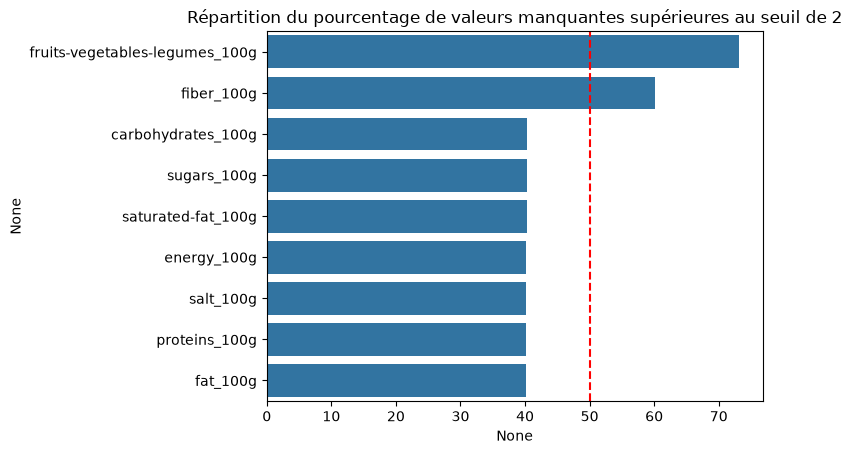

In [7]:
threshold_view = 2

filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [8]:
## On retire les features avec + de 60% de valeurs manquantes

columns_to_drop = percent_missing[percent_missing.values > threshold].index
print(columns_to_drop)

df_restr_8 = df_connu[features + ['nutriscore_grade']].drop(columns=columns_to_drop)

print(df_restr_8.shape)
df_restr_8.head()

Index(['fruits-vegetables-legumes_100g', 'fiber_100g'], dtype='str')
(965, 8)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_grade
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e


In [9]:
##il y a des lignes avec des NaN dans chaque features, il faut les supprimer ! 

df_restr_8[df_restr_8.isna().sum(axis=1) >= 5]
(df_restr_8.isna().sum(axis=1) == 7).sum()

np.int64(388)

In [10]:
df_restr_8 = df_restr_8[df_restr_8.isna().sum(axis=1) != 7] ##je supprime les lignes avec 7 valeurs manquantes.

In [11]:
print(df_restr_8.shape)
df_restr_8.head()

(577, 8)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_grade
840,697.100000,1.3,1.9,0.0009,6.7,6.400000,20.0,c
875,1928.500000,13.8,18.0,0.6490,6.0,28.000000,46.5,e
890,2524.000000,10.0,32.0,0.0100,8.0,48.000000,36.0,e
892,929.000000,1.2,0.6,0.8000,13.5,12.000000,11.8,a
946,1357.900028,12.7,0.0,0.0000,0.0,36.700001,0.0,d


In [12]:
from sklearn.impute import SimpleImputer

raw_df_restr_8 = df_restr_8.copy() ##je garde une copie du dataframe avant imputation pour pouvoir comparer les résultats après imputation.


# On sépare les features (à imputer) de la cible
features_restantes = df_restr_8.columns.drop('nutriscore_grade')

imputer = SimpleImputer(strategy='mean')

df_restr_8[features_restantes] = imputer.fit_transform(df_restr_8[features_restantes])

print(df_restr_8.isnull().sum())  # vérification : tout devrait être à 0
df_restr_8.head()

energy_100g           0
saturated-fat_100g    0
sugars_100g           0
salt_100g             0
proteins_100g         0
fat_100g              0
carbohydrates_100g    0
nutriscore_grade      0
dtype: int64


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_grade
840,697.100000,1.3,1.9,0.0009,6.7,6.400000,20.0,c
875,1928.500000,13.8,18.0,0.6490,6.0,28.000000,46.5,e
890,2524.000000,10.0,32.0,0.0100,8.0,48.000000,36.0,e
892,929.000000,1.2,0.6,0.8000,13.5,12.000000,11.8,a
946,1357.900028,12.7,0.0,0.0000,0.0,36.700001,0.0,d


Outliers 


energy_100g : 0 outliers selon Tukey
Bornes : [-1539.33 ; 3977.20]
Empty DataFrame
Columns: [energy_100g, product_name, countries_en]
Index: []

saturated-fat_100g : 22 outliers selon Tukey
Bornes : [-10.30 ; 17.70]
      saturated-fat_100g                       product_name     countries_en
6693           34.200000                      Nibs de cacao            Spain
7308           34.000000            Chocolat Noir 85% vegan           France
7282           33.333333                      Butter Powder  Germany,Ireland
7132           33.000000                     Absolute Black   United Kingdom
6526           32.400000  Pasta di cacao nero assoluto 100%            Italy
2798           31.231000                             Tester    United States
5411           29.000000      oeuf de goeland chocolat vrac           France
9536           28.000000                       Crispy wafer           France
4148           26.720000                    Turron de trufa            Spain
8094         

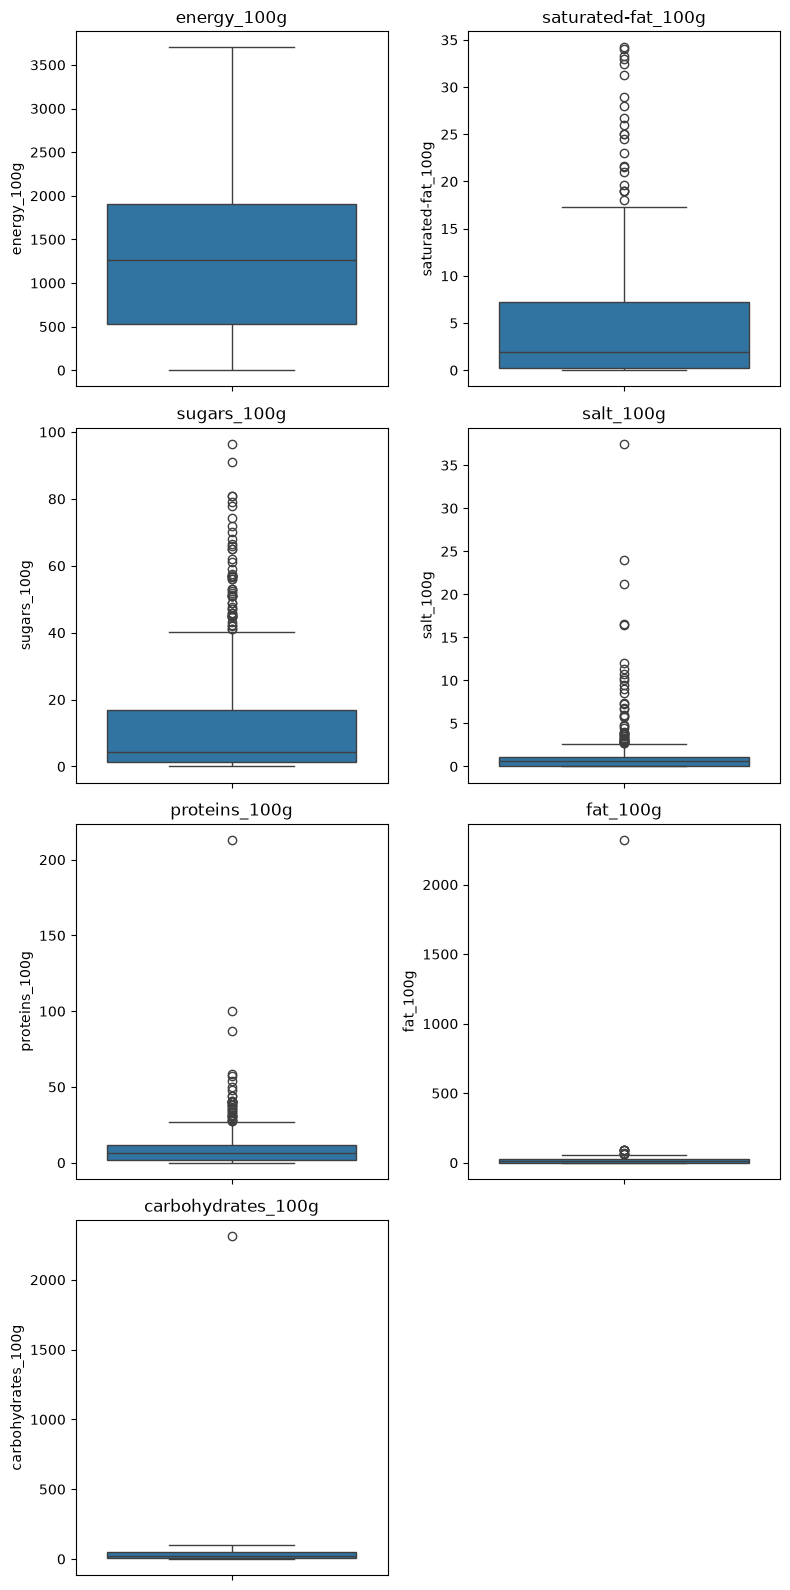

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cols = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
        'proteins_100g', 'fat_100g', 'carbohydrates_100g']

infos = df_connu.loc[df_restr_8.index, ['product_name', 'countries_en']]

fig, axs = plt.subplots(4, 2, figsize=(8, 16))

for ax, col in zip(axs.flat, cols):
    sns.boxplot(y=df_restr_8[col], ax=ax)
    ax.set_title(col)
    Q1 = df_restr_8[col].quantile(0.25)
    Q3 = df_restr_8[col].quantile(0.75)
    IQR = Q3 - Q1
    masque = (df_restr_8[col] < Q1 - 1.5*IQR) | (df_restr_8[col] > Q3 + 1.5*IQR)

    print(f"\n{col} : {masque.sum()} outliers selon Tukey")
    print(f"Bornes : [{Q1 - 1.5*IQR:.2f} ; {Q3 + 1.5*IQR:.2f}]")
    print(df_restr_8.loc[masque, [col]].join(infos)
          .sort_values(col, ascending=False).head(10).to_string())

axs.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:

masque_impossible = pd.Series(False, index=df_restr_8.index)

for col in [c for c in cols if c != 'energy_100g']:
    m = (df_restr_8[col] < 0) | (df_restr_8[col] > 100)
    print(f"\n{col} : {m.sum()} valeurs impossibles")
    if m.sum() > 0:
        print(df_restr_8.loc[m, [col]].join(infos)
              .sort_values(col, ascending=False).head(10).to_string())
    masque_impossible = masque_impossible | m

# énergie : bornes différentes
m = ~df_restr_8['energy_100g'].between(0, 3800)
print(f"\nenergy_100g : {m.sum()} valeurs impossibles")
if m.sum() > 0:
    print(df_restr_8.loc[m, ['energy_100g']].join(infos)
          .sort_values('energy_100g', ascending=False).head(10).to_string())
masque_impossible = masque_impossible | m

print(f"\nTOTAL : {masque_impossible.sum()} lignes à supprimer "
      f"({masque_impossible.mean()*100:.2f} %)")


saturated-fat_100g : 0 valeurs impossibles

sugars_100g : 0 valeurs impossibles

salt_100g : 0 valeurs impossibles

proteins_100g : 1 valeurs impossibles
      proteins_100g product_name   countries_en
2798          213.0       Tester  United States

fat_100g : 1 valeurs impossibles
      fat_100g product_name   countries_en
2798    2321.0       Tester  United States

carbohydrates_100g : 1 valeurs impossibles
      carbohydrates_100g product_name   countries_en
2798              2312.0       Tester  United States

energy_100g : 0 valeurs impossibles

TOTAL : 1 lignes à supprimer (0.17 %)


In [15]:
avant = len(df_restr_8)
df_restr_8 = df_restr_8[~masque_impossible]
print(f"{avant - len(df_restr_8)} lignes supprimées, il reste {len(df_restr_8)} lignes")

1 lignes supprimées, il reste 576 lignes


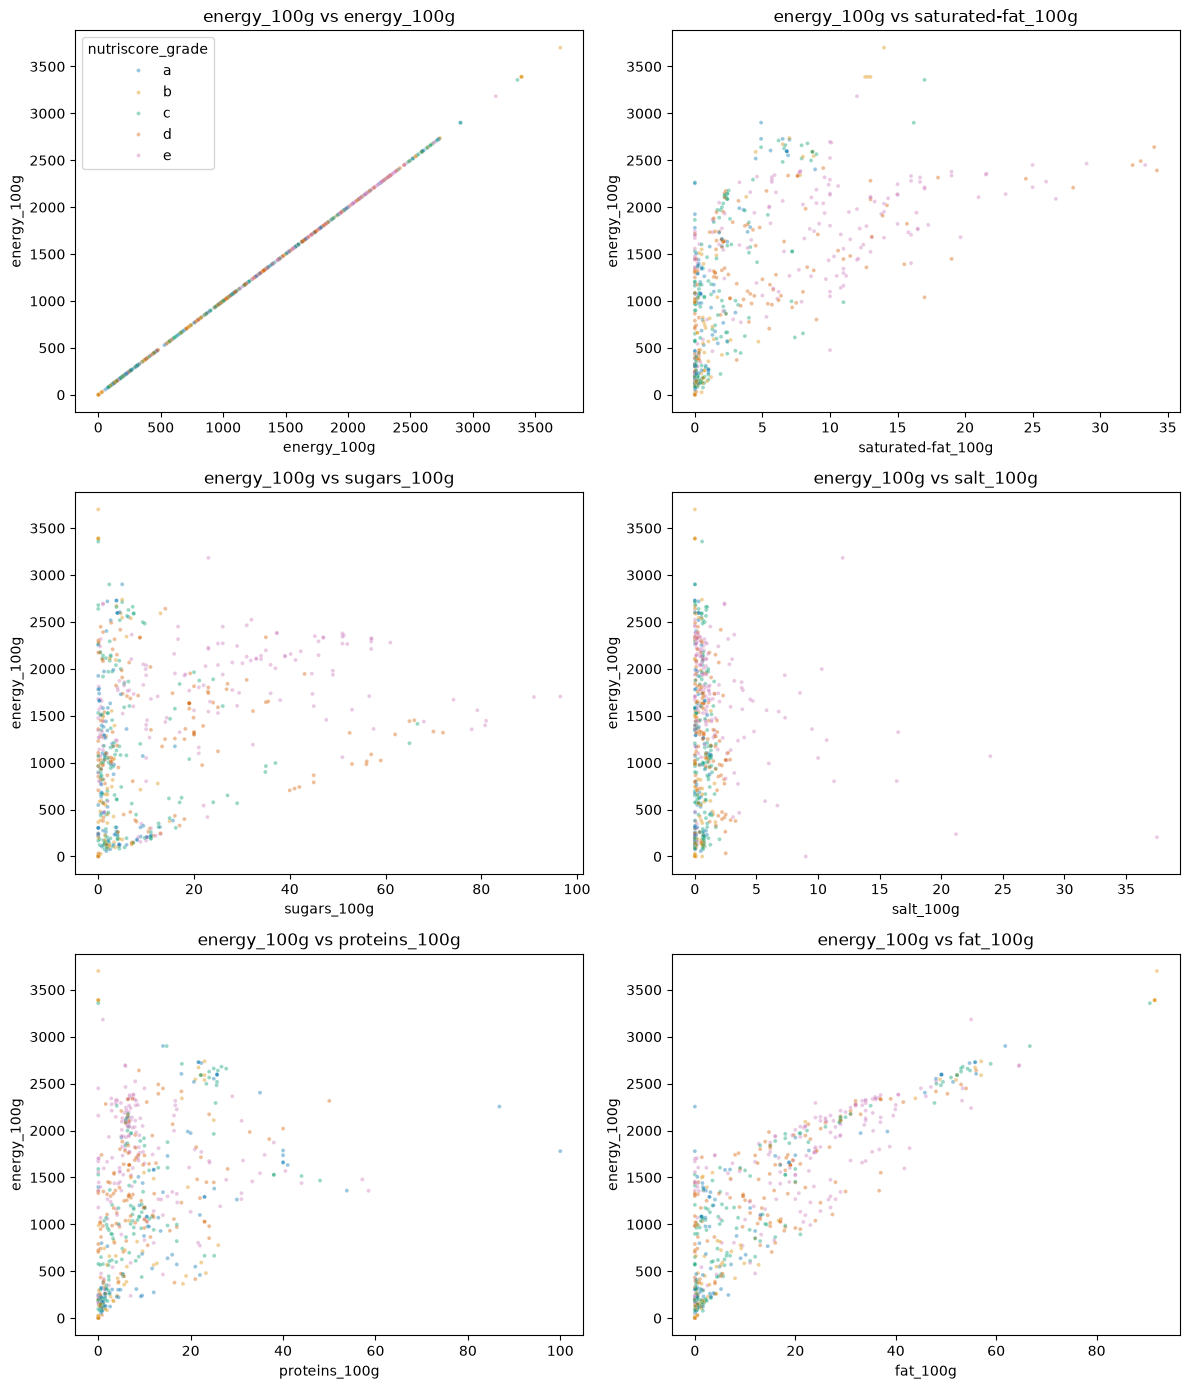

In [16]:
fig, axs = plt.subplots(3, 2, figsize=(12, 14))

for ax, col in zip(axs.flat, cols):
    sns.scatterplot(data=df_restr_8, x=col, y="energy_100g",
                    hue="nutriscore_grade", hue_order=list("abcde"),
                    palette="colorblind", alpha=0.4, s=8,
                    ax=ax, legend=(ax is axs.flat[0]))
    ax.set_title(f"energy_100g vs {col}")

plt.tight_layout()
plt.show()

RandomForest

In [17]:
from sklearn.model_selection import train_test_split

X = df_restr_8[cols]  # Seules CES colonnes sont sélectionnées, tout le reste est ignoré
y = df_restr_8['nutriscore_grade']    

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split.

In [18]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Espace de recherche des hyperparamètres
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 10, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 30)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Création du modèle avec les hyperparamètres suggérés
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # Evaluation par cross-validation
    score = cross_val_score(model, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1)
    return score.mean()

# Création de l'étude (on veut maximiser le f1_macro)
study = optuna.create_study(direction="maximize")

# Lancement de l'optimisation (50 essais)
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Résultats
print(f"Meilleurs hyperparamètres: {study.best_params}")
print(f"Meilleur f1_macro: {study.best_value:.4f}")

c:\Users\Alina\Desktop\AMU\DESU Data science\DESU_ROCHET\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 41. Best value: 0.583616: 100%|██████████| 50/50 [00:29<00:00,  1.67it/s]

Meilleurs hyperparamètres: {'n_estimators': 445, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}
Meilleur f1_macro: 0.5836


In [19]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"Accuracy test : {best_model.score(X_test, y_test):.4f}")

              precision    recall  f1-score   support

           a       0.42      0.71      0.53        14
           b       0.43      0.18      0.25        17
           c       0.50      0.42      0.46        26
           d       0.46      0.55      0.50        22
           e       0.73      0.73      0.73        37

    accuracy                           0.54       116
   macro avg       0.51      0.52      0.49       116
weighted avg       0.55      0.54      0.53       116

Accuracy test : 0.5431


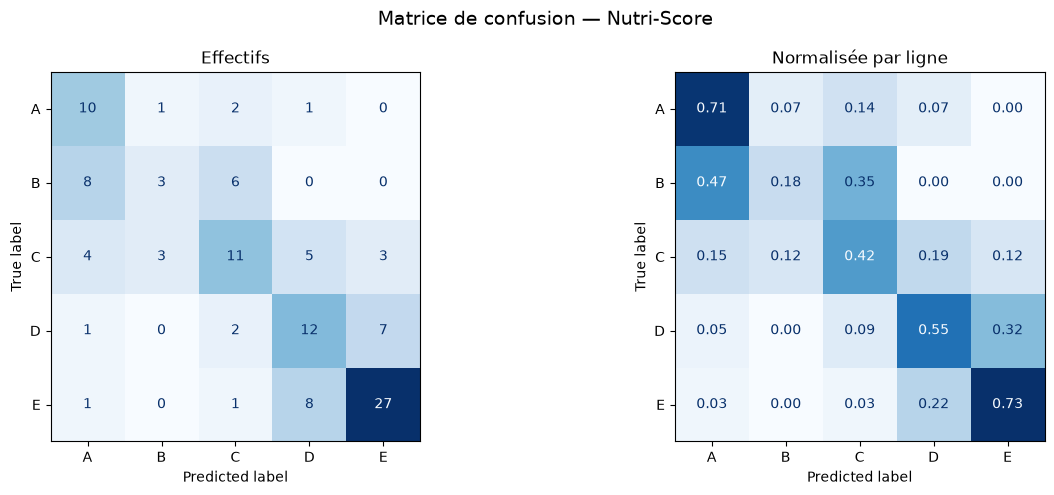

In [20]:
labels = sorted(y_train.unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, labels=labels,
    display_labels=[l.upper() for l in labels],
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Effectifs")

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, labels=labels,
    display_labels=[l.upper() for l in labels],
    cmap="Blues", normalize="true", values_format=".2f",
    ax=axes[1], colorbar=False
)
axes[1].set_title("Normalisée par ligne")

fig.suptitle("Matrice de confusion — Nutri-Score", fontsize=14)
plt.tight_layout()
plt.show()

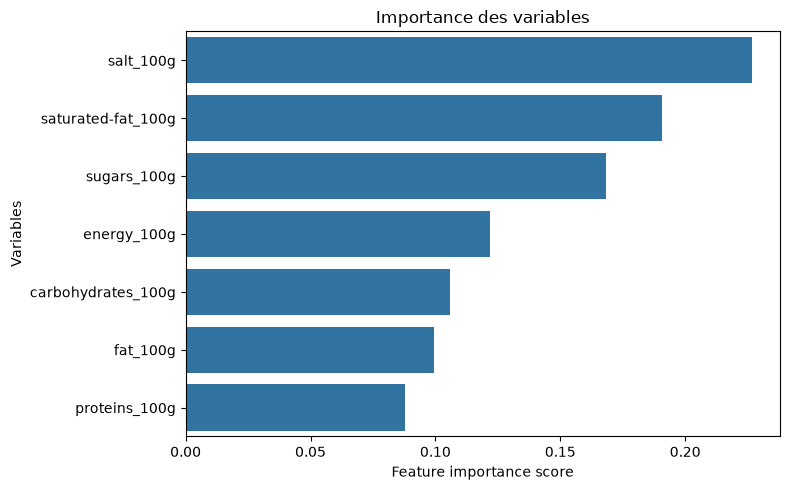

salt_100g             0.226618
saturated-fat_100g    0.190662
sugars_100g           0.168099
energy_100g           0.121828
carbohydrates_100g    0.105690
fat_100g              0.099250
proteins_100g         0.087853
dtype: float64


In [21]:
feature_scores = pd.Series(best_model.feature_importances_,
                           index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel("Feature importance score")
plt.ylabel("Variables")
plt.title("Importance des variables")
plt.tight_layout()
plt.show()

print(feature_scores)

In [22]:
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()
optuna.visualization.plot_parallel_coordinate(study).show()

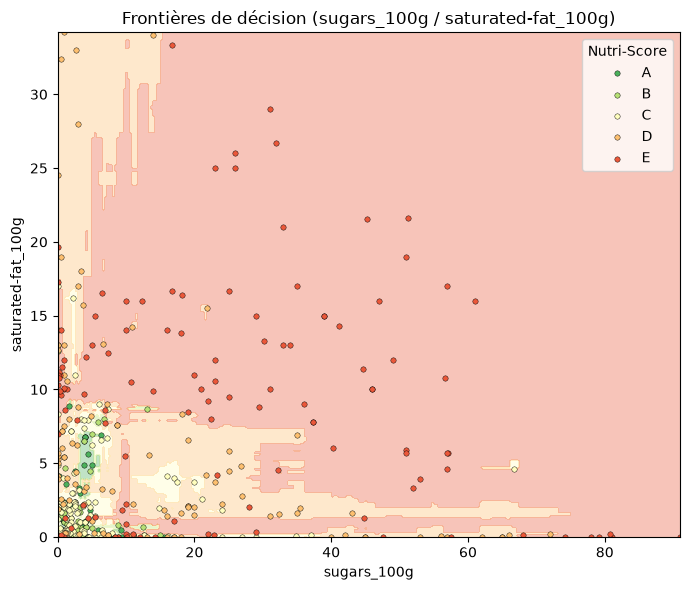

In [23]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X_df, y_ser, classifier,
                          features=("sugars_100g", "saturated-fat_100g"),
                          figsize=(7, 6), n_grid=300, sample=3000):
    f0, f1 = features
    d = pd.concat([X_df[[f0, f1]], y_ser], axis=1)
    if len(d) > sample:
        d = d.sample(sample, random_state=42)
    X2, y2 = d[[f0, f1]], d[y_ser.name]

    classes = sorted(y2.unique())
    idx = {c: i for i, c in enumerate(classes)}

    clf = classifier.fit(X2, y2)

    x_min, x_max = X2[f0].min(), X2[f0].max()
    y_min, y_max = X2[f1].min(), X2[f1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid),
                         np.linspace(y_min, y_max, n_grid))

    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[f0, f1])
    Z = pd.Series(clf.predict(grid)).map(idx).values.reshape(xx.shape)

    cmap = ListedColormap(sns.color_palette("RdYlGn_r", len(classes)).as_hex())

    fig, ax = plt.subplots(figsize=figsize)
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.35, levels=np.arange(-0.5, len(classes)))

    for c in classes:
        m = y2 == c
        ax.scatter(X2.loc[m, f0], X2.loc[m, f1], color=cmap(idx[c]),
                   label=c.upper(), edgecolor="black", linewidth=0.3, s=15)

    ax.set_xlabel(f0)
    ax.set_ylabel(f1)
    ax.set_title(f"Frontières de décision ({f0} / {f1})")
    ax.legend(title="Nutri-Score")
    plt.tight_layout()
    plt.show()

plot_decision_regions(
    X_train, y_train,
    RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
)

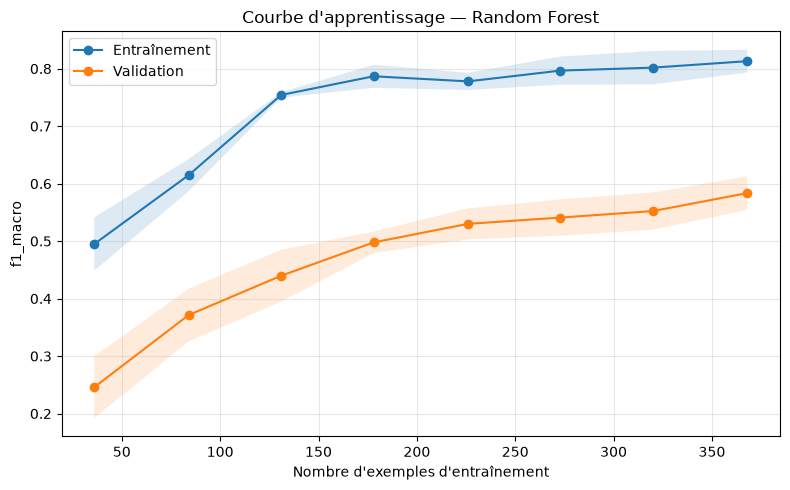

In [24]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring="f1_macro", n_jobs=-1, random_state=42
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Entraînement")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, "o-", label="Validation")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("f1_macro")
plt.title("Courbe d'apprentissage — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
print("df_restr_8 :", len(df_restr_8))
print("X_train    :", len(X_train))
print("X_test     :", len(X_test))

df_restr_8 : 576
X_train    : 460
X_test     : 116
